# RateAhead — Exploratory Data Analysis (EDA) filtering

This notebook is **pre-filtering** EDA for the Kaggle *Movie Industry* dataset.  
Goal: **identify data quality issues and biases** and turn them into **defensible filtering / cleaning decisions**.

**Assumption:** dataset CSV is located at: `data/raw/movies.csv`


In [3]:
# If running in a fresh environment, install dependencies (optional)
# !pip install -q pandas numpy matplotlib scikit-learn pyyaml tqdm torch

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


In [5]:
# Load data
DATA_PATH = "../data/raw/movies.csv"
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}. Put the Kaggle CSV there."

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7668, 15)


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## 1) Dataset overview (schema + basic sanity)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [7]:
# Basic stats for numeric columns
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
year,7668.0,2.000405e+03,1.115351e+01,1980.0,1991.0,2000.0,2010.0,2.020000e+03
score,7665.0,6.390411e+00,9.688416e-01,1.9,5.8,6.5,7.1,9.300000e+00
votes,7665.0,8.810850e+04,1.633238e+05,7.0,9100.0,33000.0,93000.0,2.400000e+06
budget,5497.0,3.558988e+07,4.145730e+07,3000.0,10000000.0,20500000.0,45000000.0,3.560000e+08
gross,7479.0,7.850054e+07,1.657251e+08,309.0,4532055.5,20205757.0,76016691.5,2.847246e+09
runtime,7664.0,1.072616e+02,1.858125e+01,55.0,95.0,104.0,116.0,3.660000e+02


## 2) Target analysis — `score` (IMDb score)

In [8]:
target_col = "score"
assert target_col in df.columns, f"Expected target column '{target_col}' not found. Columns: {list(df.columns)}"

score = df[target_col]
print("Missing score (%):", 100 * score.isna().mean())
score.describe()


Missing score (%): 0.03912363067292645


count    7665.000000
mean        6.390411
std         0.968842
min         1.900000
25%         5.800000
50%         6.500000
75%         7.100000
max         9.300000
Name: score, dtype: float64

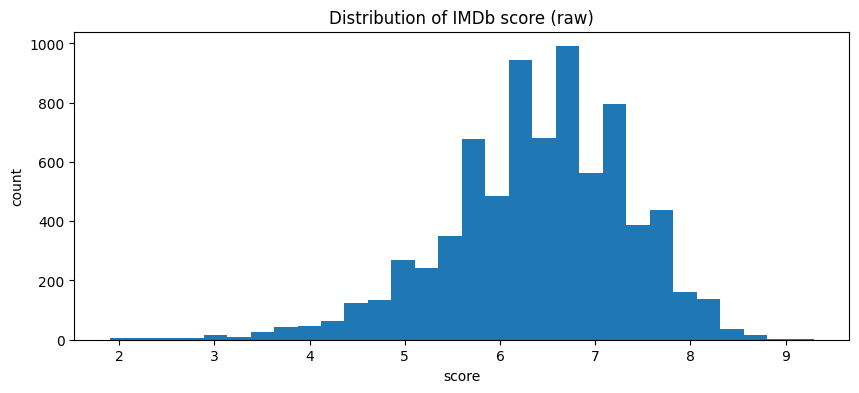

In [9]:
# Score distribution
plt.figure()
plt.hist(score.dropna(), bins=30)
plt.title("Distribution of IMDb score (raw)")
plt.xlabel("score")
plt.ylabel("count")
plt.show()


In [10]:
# Outlier check (very low/high scores)
# You can later use this to decide if you want to clip or drop extreme outliers
q = score.quantile([0.001, 0.01, 0.99, 0.999])
q


0.001    2.2
0.010    3.7
0.990    8.3
0.999    8.8
Name: score, dtype: float64

## 3) Reliability analysis — `votes` vs `score`

Rows with both votes & score: 7665


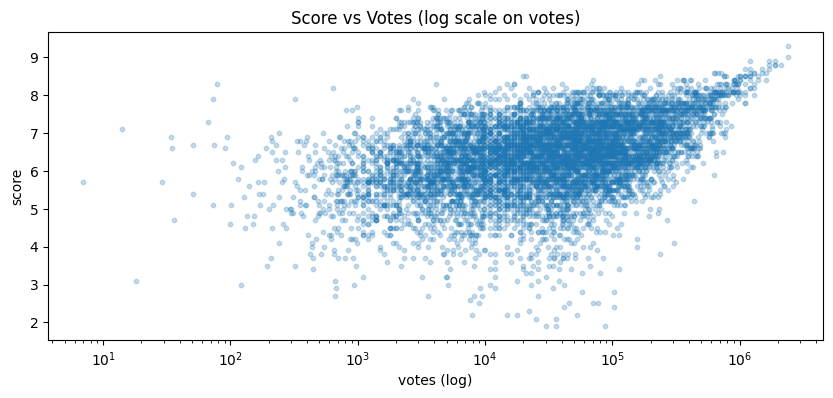

In [11]:
# Many IMDb scores are unreliable with very few votes.
# We'll inspect the relationship and the variance at low vote counts.

votes_col = "votes"
assert votes_col in df.columns, f"Expected column '{votes_col}' not found."

tmp = df[[votes_col, target_col]].dropna()
print("Rows with both votes & score:", len(tmp))

plt.figure()
plt.scatter(tmp[votes_col], tmp[target_col], alpha=0.25, s=10)
plt.xscale("log")
plt.title("Score vs Votes (log scale on votes)")
plt.xlabel("votes (log)")
plt.ylabel("score")
plt.show()


In [12]:
# Quantify score stability by vote buckets
# This helps justify a votes threshold like 50/100/500 based on observed variance.

bins = [0, 10, 50, 100, 200, 500, 1000, 5000, 20000, np.inf]
labels = ["<=10", "11-50", "51-100", "101-200", "201-500", "501-1k", "1k-5k", "5k-20k", "20k+"]
tmp2 = tmp.copy()
tmp2["vote_bucket"] = pd.cut(tmp2[votes_col], bins=bins, labels=labels, right=True)

bucket_stats = tmp2.groupby("vote_bucket")[target_col].agg(["count", "mean", "std", "min", "max"])
bucket_stats


C:\Users\yuval\AppData\Local\Temp\ipykernel_30172\177524071.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = tmp2.groupby("vote_bucket")[target_col].agg(["count", "mean", "std", "min", "max"])


,count,mean,std,min,max
vote_bucket,,,,,
<=10,1,5.700000,NaN,5.7,5.7
11-50,6,5.683333,1.547148,3.1,7.1
51-100,10,6.550000,1.194664,4.6,8.3
101-200,20,5.295000,0.925359,3.0,6.6
201-500,72,5.516667,0.977061,3.4,7.9
501-1k,179,5.616201,0.983410,2.7,8.2
1k-5k,969,5.910939,0.849930,2.7,8.3
5k-20k,1804,6.164024,0.904501,2.2,8.5
20k+,4604,6.629279,0.928768,1.9,9.3


## 4) Missing values analysis (rate + patterns)

In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.to_frame("missing_%").head(25)


,missing_%
budget,28.312467
gross,2.464789
rating,1.004173
company,0.221701
runtime,0.052165
score,0.039124
votes,0.039124
country,0.039124
writer,0.039124
released,0.026082


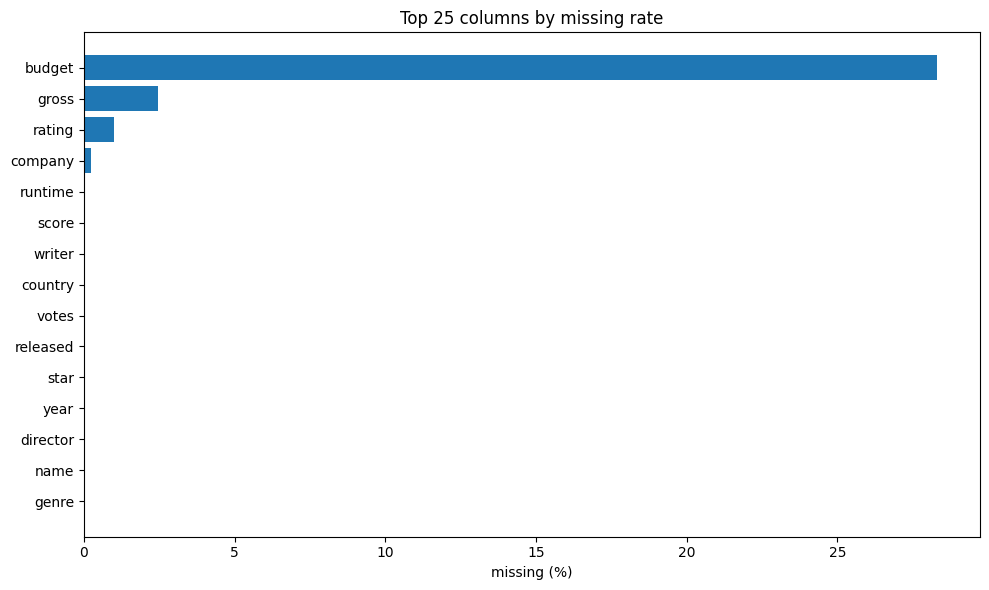

In [14]:
# Visualize missingness by column (top N)
top_n = 25
top = missing_pct.head(top_n).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top.index, top.values)
plt.title(f"Top {top_n} columns by missing rate")
plt.xlabel("missing (%)")
plt.tight_layout()
plt.show()


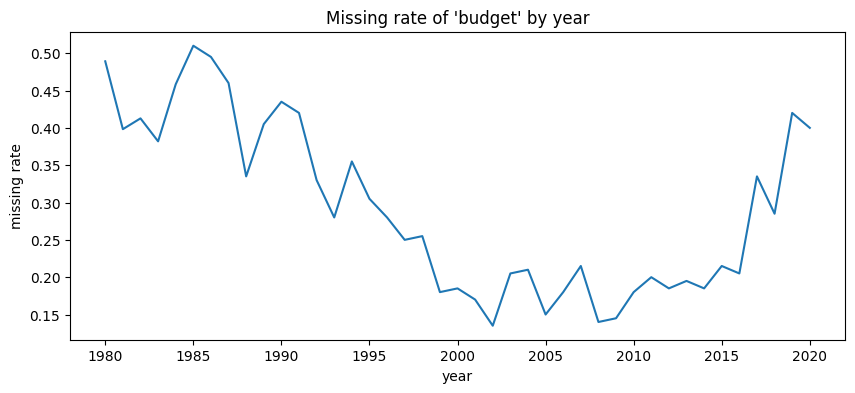

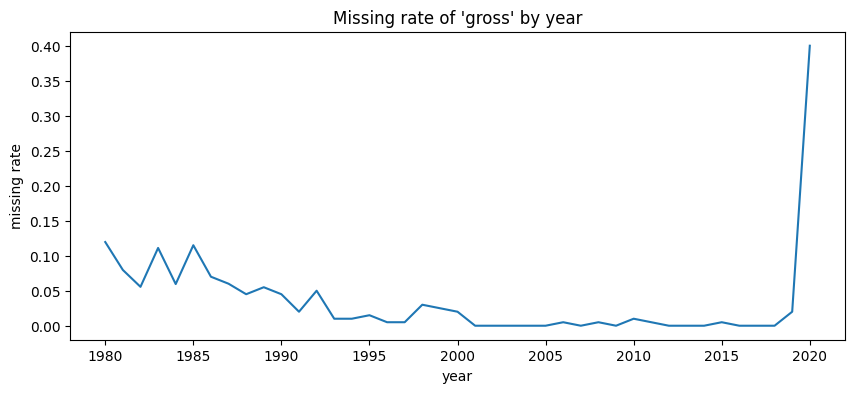

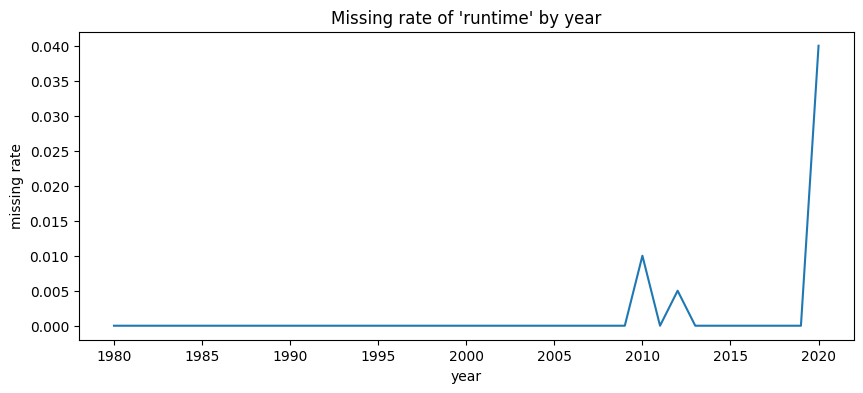

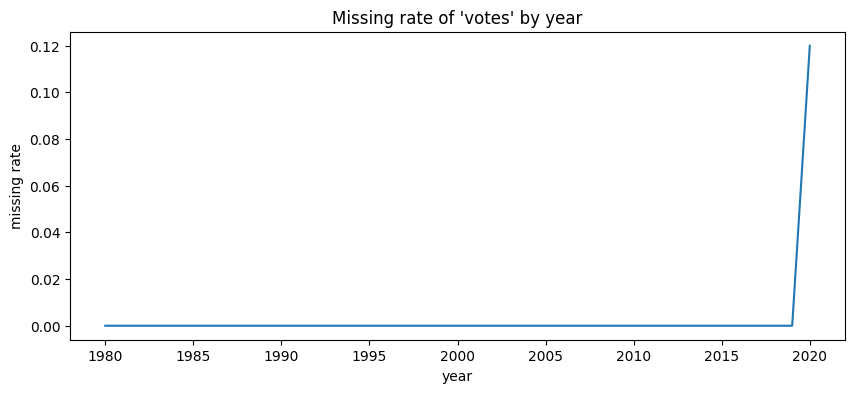

In [15]:
# Missingness correlation with year (example): are older movies missing budget/gross more?
year_col = "year"
if year_col in df.columns:
    cols_to_check = [c for c in ["budget", "gross", "runtime", "votes"] if c in df.columns]
    for c in cols_to_check:
        miss_flag = df[c].isna().astype(int)
        tmp_year = df[[year_col]].copy()
        tmp_year["missing"] = miss_flag
        grp = tmp_year.groupby(year_col)["missing"].mean()
        # Plot only if enough years exist
        if len(grp) > 5:
            plt.figure()
            plt.plot(grp.index, grp.values)
            plt.title(f"Missing rate of '{c}' by year")
            plt.xlabel("year")
            plt.ylabel("missing rate")
            plt.show()
else:
    print("No 'year' column found; skipping year-based missingness plots.")


## 5) Numeric feature distributions (skew + impossible values)

In [16]:
numeric_candidates = [c for c in ["budget", "gross", "runtime", "votes", "year"] if c in df.columns]
numeric_candidates


['budget', 'gross', 'runtime', 'votes', 'year']

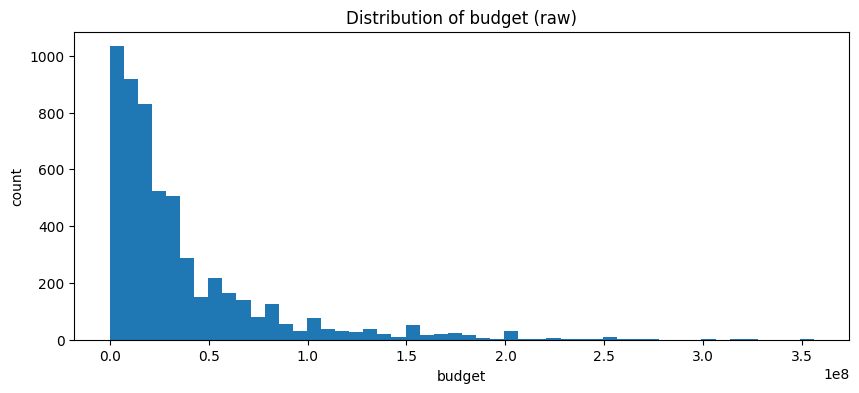

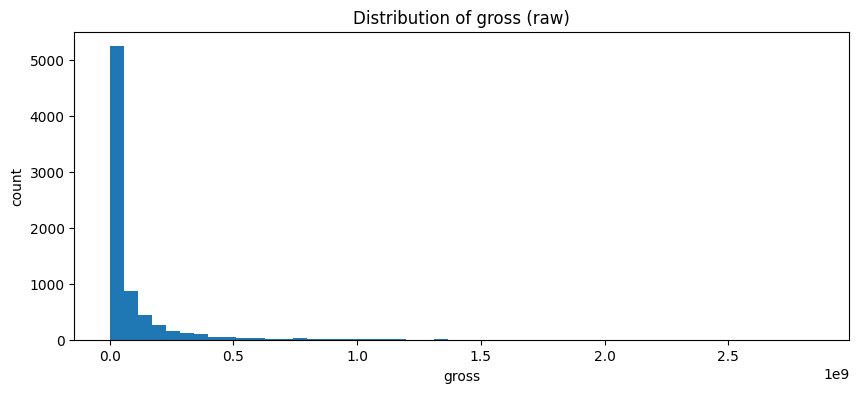

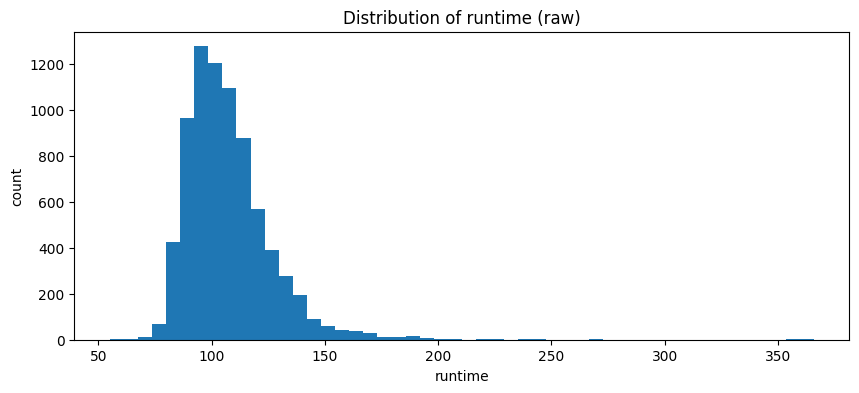

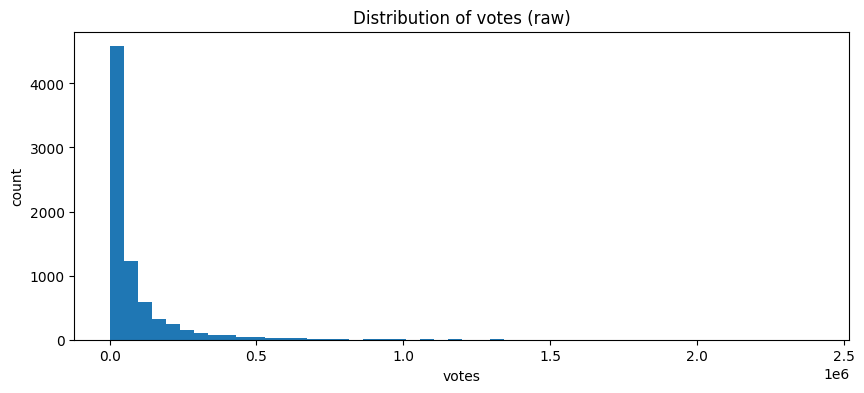

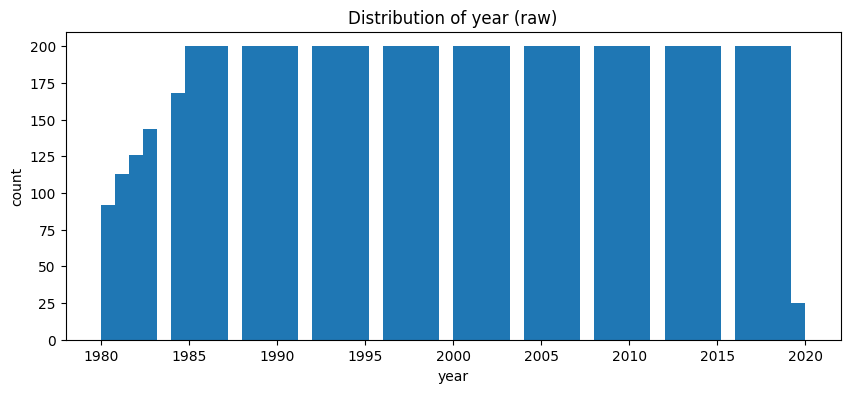

In [17]:
# Histograms (raw scale)
for c in numeric_candidates:
    plt.figure()
    x = df[c].dropna()
    plt.hist(x, bins=50)
    plt.title(f"Distribution of {c} (raw)")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()


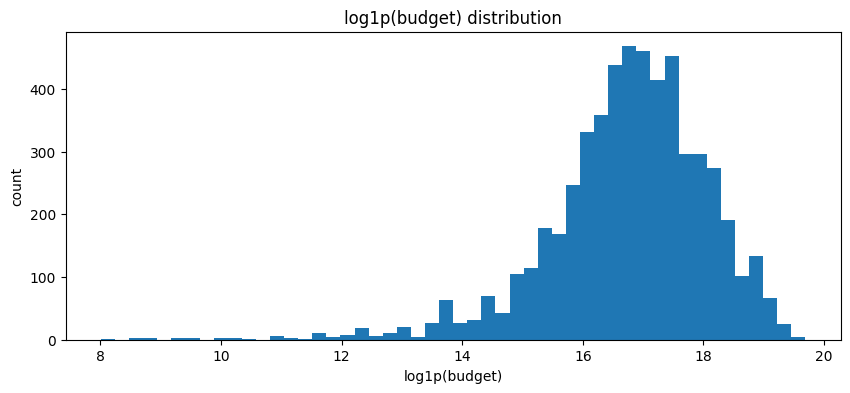

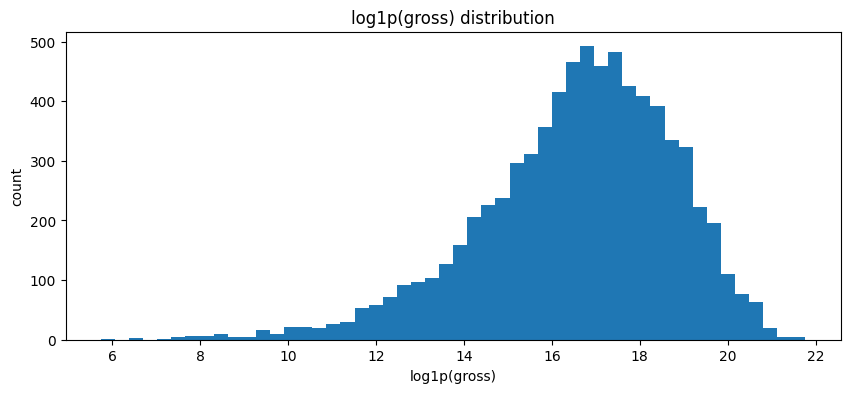

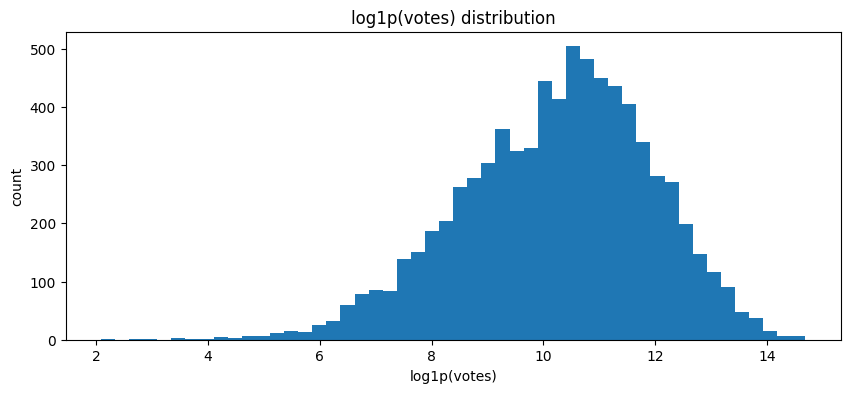

In [18]:
# Histograms on log scale for heavy-tailed columns (budget/gross/votes)
for c in [c for c in ["budget", "gross", "votes"] if c in df.columns]:
    x = df[c].dropna()
    x = x[x >= 0]
    plt.figure()
    plt.hist(np.log1p(x), bins=50)
    plt.title(f"log1p({c}) distribution")
    plt.xlabel(f"log1p({c})")
    plt.ylabel("count")
    plt.show()


In [19]:
# Identify suspicious values (examples)
checks = {}

if "runtime" in df.columns:
    checks["runtime<=0"] = int((df["runtime"] <= 0).sum())
    checks["runtime<30"] = int((df["runtime"] < 30).sum())
    checks["runtime>300"] = int((df["runtime"] > 300).sum())

for c in ["budget", "gross", "votes"]:
    if c in df.columns:
        checks[f"{c}==0"] = int((df[c] == 0).sum())
        checks[f"{c}<0"] = int((df[c] < 0).sum())

pd.Series(checks, name="count")


runtime<=0     0
runtime<30     0
runtime>300    2
budget==0      0
budget<0       0
gross==0       0
gross<0        0
votes==0       0
votes<0        0
Name: count, dtype: int64

## 6) Temporal analysis — `year` bias

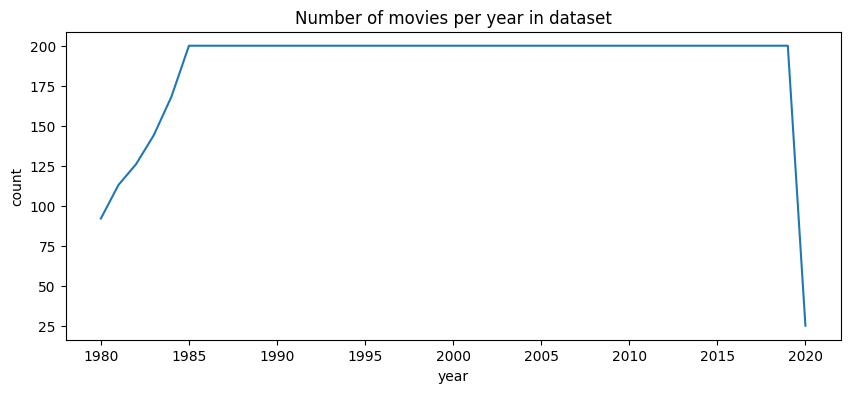

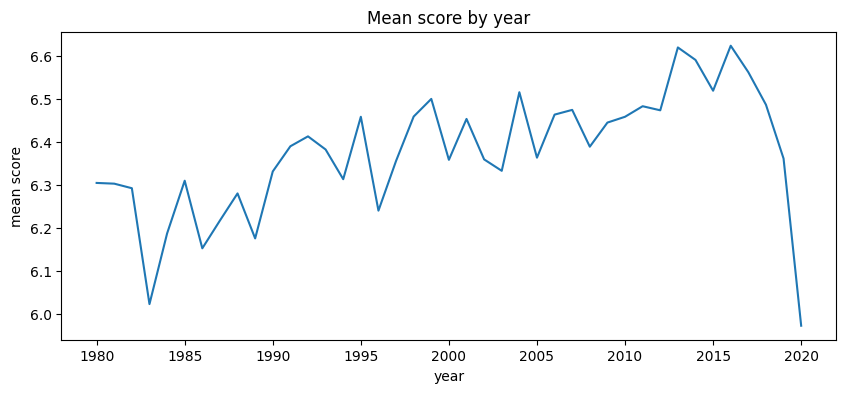

In [20]:
if "year" in df.columns:
    year_counts = df["year"].value_counts().sort_index()
    plt.figure(figsize=(10,4))
    plt.plot(year_counts.index, year_counts.values)
    plt.title("Number of movies per year in dataset")
    plt.xlabel("year")
    plt.ylabel("count")
    plt.show()

    # Score vs year (mean)
    if "score" in df.columns:
        year_score = df.dropna(subset=["year", "score"]).groupby("year")["score"].mean()
        plt.figure(figsize=(10,4))
        plt.plot(year_score.index, year_score.values)
        plt.title("Mean score by year")
        plt.xlabel("year")
        plt.ylabel("mean score")
        plt.show()
else:
    print("No 'year' column found; skipping temporal analysis.")


## 7) Categorical cardinality (long-tail)

In [21]:
cat_candidates = [c for c in ["genre", "director", "star", "company", "country", "rating"] if c in df.columns]
cat_candidates


['genre', 'director', 'star', 'company', 'country', 'rating']

In [22]:
# Cardinality + top categories
summary = []
for c in cat_candidates:
    nunique = df[c].nunique(dropna=True)
    missing = df[c].isna().mean() * 100
    summary.append({"col": c, "nunique": nunique, "missing_%": missing})
pd.DataFrame(summary).sort_values("nunique", ascending=False)


,col,nunique,missing_%
1,director,2949,0.000000
2,star,2814,0.013041
3,company,2385,0.221701
4,country,59,0.039124
0,genre,19,0.000000
5,rating,12,1.004173


In [23]:
# Long-tail visualization: how many categories are rare?
# Example: "director" often has huge cardinality; you may want to group rare categories into 'Other'
for c in cat_candidates:
    vc = df[c].value_counts(dropna=True)
    if len(vc) == 0:
        continue
    rare_1 = int((vc == 1).sum())
    rare_5 = int((vc < 5).sum())
    print(f"{c:10s} | total categories={len(vc):6d} | appear once={rare_1:6d} | appear <5 times={rare_5:6d}")


genre      | total categories=    19 | appear once=     3 | appear <5 times=     5
director   | total categories=  2949 | appear once=  1558 | appear <5 times=  2522
star       | total categories=  2814 | appear once=  1771 | appear <5 times=  2439
company    | total categories=  2385 | appear once=  1695 | appear <5 times=  2178
country    | total categories=    59 | appear once=    11 | appear <5 times=    24
rating     | total categories=    12 | appear once=     2 | appear <5 times=     3


In [24]:
# Show top 15 categories for each categorical feature
for c in cat_candidates:
    print("\n", "="*80)
    print("Top categories for:", c)
    display(df[c].value_counts(dropna=False).head(15))



Top categories for: genre


genre
Comedy       2245
Action       1705
Drama        1518
Crime         551
Biography     443
Adventure     427
Animation     338
Horror        322
Fantasy        44
Mystery        20
Thriller       16
Family         11
Sci-Fi         10
Romance        10
Western         3
Name: count, dtype: int64


Top categories for: director


director
Woody Allen          38
Clint Eastwood       31
Directors            28
Steven Spielberg     27
Ron Howard           24
Ridley Scott         23
Steven Soderbergh    23
Joel Schumacher      22
Barry Levinson       20
Martin Scorsese      19
Tim Burton           19
Garry Marshall       18
Oliver Stone         18
Richard Linklater    17
Spike Lee            17
Name: count, dtype: int64


Top categories for: star


...

company
Universal Pictures           377
Warner Bros.                 334
Columbia Pictures            332
Paramount Pictures           320
Twentieth Century Fox        240
New Line Cinema              174
Touchstone Pictures          132
Metro-Goldwyn-Mayer (MGM)    125
Walt Disney Pictures         123
TriStar Pictures              94
Dreamworks Pictures           76
Miramax                       74
Fox 2000 Pictures             63
Summit Entertainment          60
Orion Pictures                60
Name: count, dtype: int64


Top categories for: country


country
United States     5475
United Kingdom     816
France             279
Canada             190
Germany            117
Australia           92
Japan               81
India               62
Italy               61
Spain               47
Hong Kong           45
Ireland             43
China               40
South Korea         35
Denmark             32
Name: count, dtype: int64


Top categories for: rating


rating
R            3697
PG-13        2112
PG           1252
Not Rated     283
G             153
NaN            77
Unrated        52
NC-17          23
TV-MA           9
TV-PG           5
X               3
Approved        1
TV-14           1
Name: count, dtype: int64

## 8) Feature–target relationships (signal check)

In [25]:
# Numeric correlations (raw)
num_cols = [c for c in ["budget", "gross", "runtime", "votes", "year", "score"] if c in df.columns]
corr = df[num_cols].corr(numeric_only=True)
corr


,budget,gross,runtime,votes,year,score
budget,1.000000,0.740395,0.320447,0.442429,0.329321,0.076254
gross,0.740395,1.000000,0.245216,0.630757,0.257486,0.186258
runtime,0.320447,0.245216,1.000000,0.309212,0.120811,0.399451
votes,0.442429,0.630757,0.309212,1.000000,0.222945,0.409182
year,0.329321,0.257486,0.120811,0.222945,1.000000,0.097995
score,0.076254,0.186258,0.399451,0.409182,0.097995,1.000000


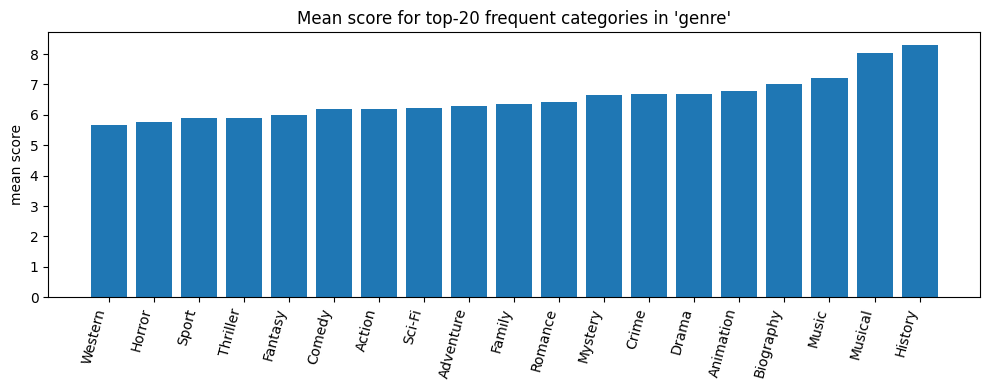

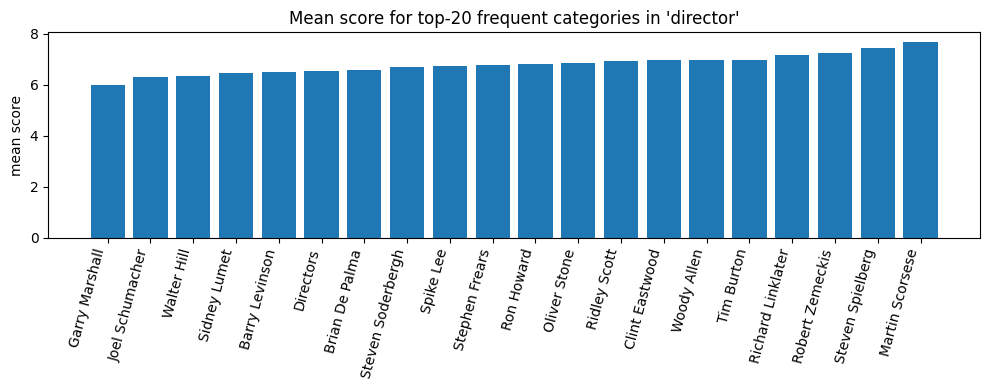

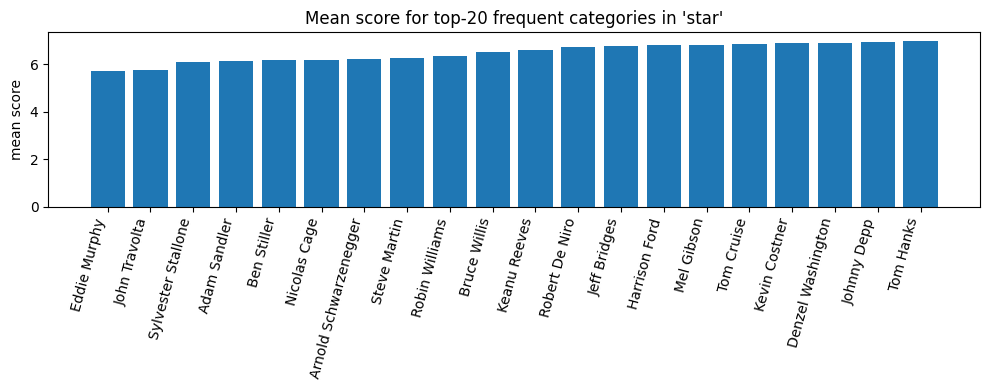

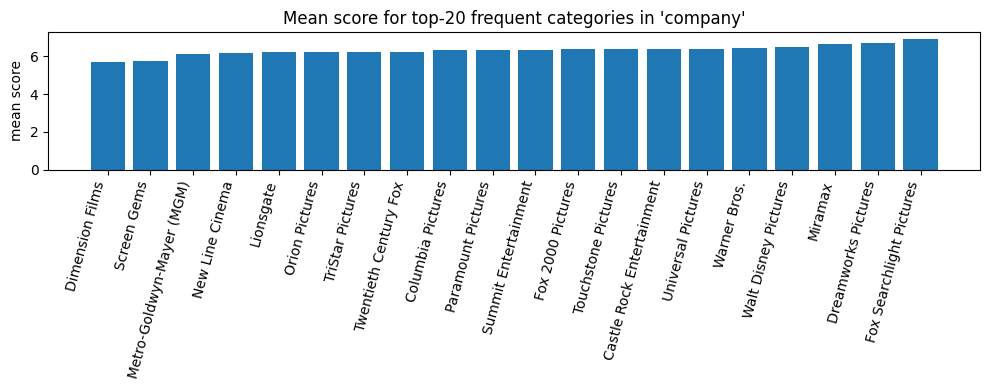

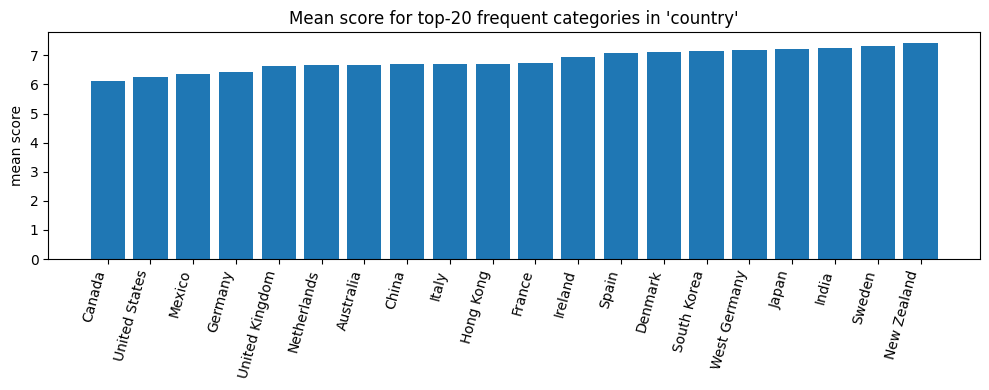

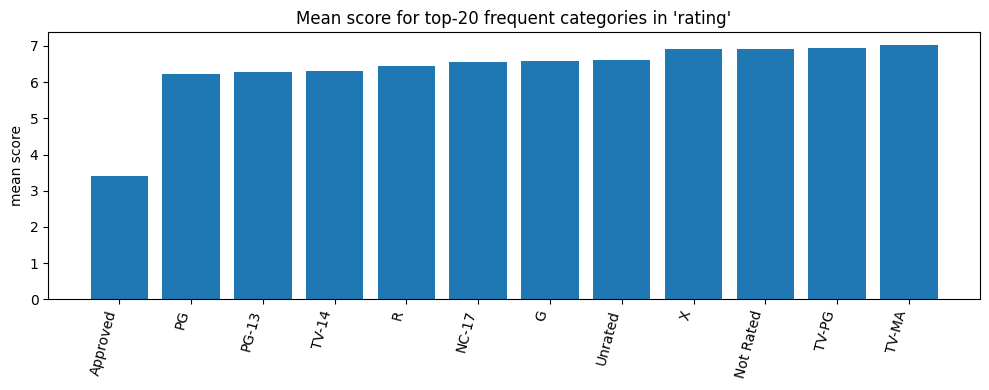

In [26]:
# Simple categorical signal: mean score by category (top K by frequency)
# Use this to see if a categorical column is informative or too noisy.
K = 20
for c in cat_candidates:
    tmp = df[[c, "score"]].dropna()
    if tmp.empty:
        continue
    vc = tmp[c].value_counts()
    top_cats = vc.head(K).index
    means = tmp[tmp[c].isin(top_cats)].groupby(c)["score"].mean().sort_values()
    plt.figure(figsize=(10,4))
    plt.bar(means.index.astype(str), means.values)
    plt.title(f"Mean score for top-{K} frequent categories in '{c}'")
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("mean score")
    plt.tight_layout()
    plt.show()


## 9) Duplicate & consistency checks

In [27]:
# Duplicates by (name, year) is a common check for movie datasets
name_col = "name"
if name_col in df.columns and "year" in df.columns:
    dup_count = df.duplicated(subset=[name_col, "year"]).sum()
    print("Duplicates by (name, year):", int(dup_count))

    # Show a few duplicate groups (if any)
    dup_rows = df[df.duplicated(subset=[name_col, "year"], keep=False)].sort_values([name_col, "year"])
    dup_rows.head(20)
else:
    print("Missing 'name' or 'year' column; skipping duplicates check.")


Duplicates by (name, year): 0


## 10) Turn EDA into a filtering plan (decision log)

In [28]:
# Fill this decision log based on what you observed above.
# This becomes a key part of your report: every filtering rule is justified by EDA evidence.

decision_log = pd.DataFrame([
    {
        "Issue": "Missing target (score)",
        "Evidence (EDA)": "Score missing rate shown in section 2",
        "Planned action": "Drop rows with missing score",
        "Parameter / threshold": "score is NA",
    },
    {
        "Issue": "Unreliable scores with few votes",
        "Evidence (EDA)": "High variance in score for low vote buckets (section 3)",
        "Planned action": "Filter movies with votes below threshold",
        "Parameter / threshold": "TBD after inspecting bucket std",
    },
    {
        "Issue": "Skewed numeric features (budget/gross/votes)",
        "Evidence (EDA)": "Heavy-tailed distributions (section 5)",
        "Planned action": "Apply log1p transform (and handle zeros)",
        "Parameter / threshold": "log1p(x)",
    },
    {
        "Issue": "Rare categories in high-cardinality features",
        "Evidence (EDA)": "Many categories appear once / <5 times (section 7)",
        "Planned action": "Group rare categories into 'Other' and keep top-N",
        "Parameter / threshold": "min_freq=TBD (e.g., 5)",
    },
    {
        "Issue": "Unrealistic runtime / negative values",
        "Evidence (EDA)": "runtime<30, runtime>300, negatives in section 5",
        "Planned action": "Remove impossible values; optionally clip extremes",
        "Parameter / threshold": "TBD based on counts",
    },
])

decision_log


,Issue,Evidence (EDA),Planned action,Parameter / threshold
0,Missing target (score),Score missing rate shown in section 2,Drop rows with missing score,score is NA
1,Unreliable scores with few votes,High variance in score for low vote buckets (s...,Filter movies with votes below threshold,TBD after inspecting bucket std
2,Skewed numeric features (budget/gross/votes),Heavy-tailed distributions (section 5),Apply log1p transform (and handle zeros),log1p(x)
3,Rare categories in high-cardinality features,Many categories appear once / <5 times (sectio...,Group rare categories into 'Other' and keep top-N,"min_freq=TBD (e.g., 5)"
4,Unrealistic runtime / negative values,"runtime<30, runtime>300, negatives in section 5",Remove impossible values; optionally clip extr...,TBD based on counts


In [29]:
# Export the decision log (optional)
os.makedirs("data/processed", exist_ok=True)
decision_log.to_csv("data/processed/eda_decision_log.csv", index=False)
print("Saved: data/processed/eda_decision_log.csv")


Saved: data/processed/eda_decision_log.csv
